In [17]:
%pip install --upgrade pip -q
%pip install neo4j -q
%pip install python-dotenv -q
%pip install py2neo networkx -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 

# Preamble

In [4]:
from datetime import datetime
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv

from neo4j import GraphDatabase

# visualization of the graph here
import networkx as nx
from py2neo import Graph
from IPython.display import HTML, display
import json

In [5]:
start_date = datetime(2025, 7, 11)

# Loading aggregated data

Run the download_data.sh script first.  

## RQ1

In [69]:
aggr_rua_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=rua_addresses/").rename(columns={"sum(count)": "count"})
aggr_ruf_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=ruf_addresses/").rename(columns={"sum(count)": "count"})

aggr_rua_pdf["rua_apex_domain"] = aggr_rua_pdf['rua_apex_domain'] = aggr_rua_pdf['rua_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})
aggr_ruf_pdf["ruf_apex_domain"] = aggr_ruf_pdf['ruf_apex_domain'] = aggr_ruf_pdf['ruf_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})

aggr_rua_ruf_pdf = pd.concat([
    aggr_rua_pdf.rename(columns={"rua_apex_domain": "rua_ruf_apex_domain"}), 
    aggr_ruf_pdf.rename(columns={"ruf_apex_domain": "rua_ruf_apex_domain"})
], ignore_index=True).drop(columns=["source", "year", "month", "day"]
).groupby("rua_ruf_apex_domain", as_index=False).agg(count=("count", "sum")
).sort_values("count", ascending=False)
aggr_rua_ruf_pdf["percent"] = aggr_rua_ruf_pdf["count"] / aggr_rua_ruf_pdf["count"].sum() * 100

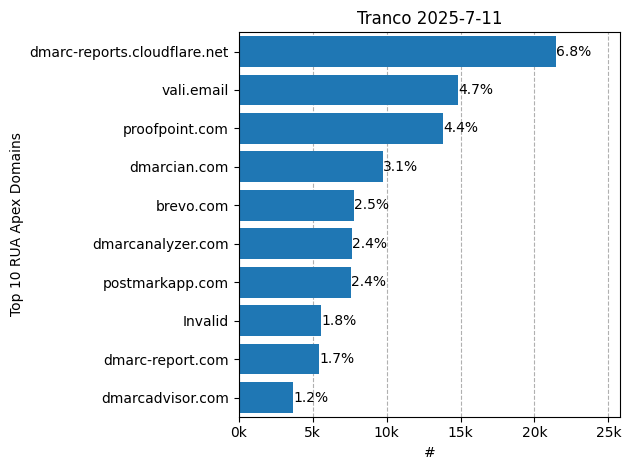

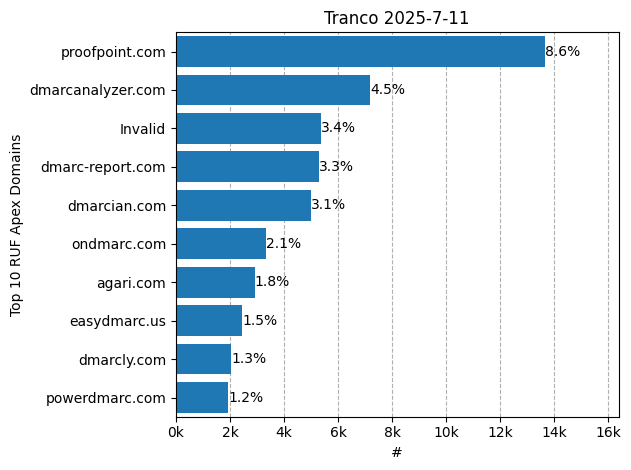

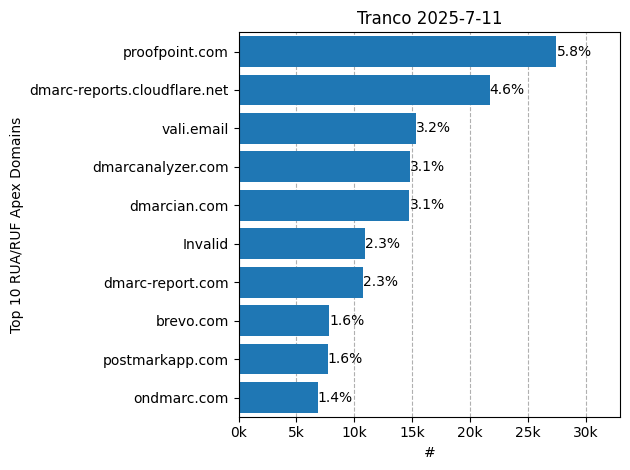

In [70]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel, start_date):
    plt.figure()

    _ = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.title(f"Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.xlim(0, top_n["count"].max() * 1.2)
    thousands = ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
    plt.gca().xaxis.set_major_formatter(thousands)
    plt.gca().set_axisbelow(True)
    plt.gca().xaxis.grid(True, linestyle='--')

    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top

    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()


_plot_dmarc_ruaruf_tag(aggr_rua_pdf.head(10), "rua_apex_domain", "Top 10 RUA Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_ruf_pdf.head(10), "ruf_apex_domain", "Top 10 RUF Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_rua_ruf_pdf.head(10), "rua_ruf_apex_domain", "Top 10 RUA/RUF Apex Domains", start_date)

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  

### Neo4j connection

In [6]:
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.uri = uri
        self.user = user
        self.password = password
        self.driver = None

    def __enter__(self):
        """Enter the context manager - establish connection"""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the context manager - close connection"""
        if self.driver:
            self.driver.close()

    def test_connection(self):
        with self.driver.session() as session:
            result = session.run("RETURN 'Connection successful' as message")
            print(result.single()["message"])

    def query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]

    def query_to_df(self, query, parameters=None):
        results = self.query(query, parameters)
        return pd.DataFrame(results)

    def write_query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return result.consume().counters

load_dotenv()
NEO4J_PASSWD = os.getenv('NEO4J_PASSWD')
if not NEO4J_PASSWD:
    raise ValueError("NEO4J_PASSWD not found in environment variables")

URI = "bolt://localhost:7687"
AUTH = ("neo4j", NEO4J_PASSWD)

Warning! RUN THIS ONLY ONCE TO SET UP THE DATABASE

In [ ]:
with Neo4jConnection(URI, *AUTH) as conn:
    conn.test_connection()
    conn.write_query("CREATE INDEX vertices_id_index IF NOT EXISTS FOR (n:Vertices) ON (n.id)")
    conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row
            CREATE (:Vertices {id: row.id})
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    result = conn.query("MATCH (n:Vertices) RETURN count(n) as total_vertices")
    print(f"Total vertices in database: {result[0]['total_vertices']}")

    result_rua = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///rua_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUA]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUA edges created: {result_rua.relationships_created}")

    result_ruf = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///ruf_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUF]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUF edges created: {result_ruf.relationships_created}")

Connection successful


Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: CALL subquery without a variable scope clause is now deprecated. Use CALL () { ... }} {position: line: 2, column: 9, offset: 9} for query: '\n        CALL {\n            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row\n            CREATE (:Vertices {id: row.id})\n        } IN TRANSACTIONS OF 5000 ROWS\n    '


In [ ]:
def visualize_with_existing_connection(conn, query, limit=50):
    # Get data using your existing connection
    data = conn.query(f"{query} LIMIT {limit}")

    # Create NetworkX graph
    G = nx.DiGraph()  # Directed graph for RUA/RUF relationships

    # Process the data
    for record in data:
        if 'source' in record and 'target' in record:
            G.add_edge(record['source'], record['target'], 
                      rel_type=record.get('relationship', 'CONNECTED'))

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Different colors for different relationship types
    edge_colors = []
    for u, v, d in G.edges(data=True):
        if d.get('rel_type') == 'RUA':
            edge_colors.append('red')
        elif d.get('rel_type') == 'RUF':
            edge_colors.append('blue')
        else:
            edge_colors.append('gray')

    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', 
                          node_size=300, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, 
                          arrows=True, arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    plt.title(f"Graph Visualization ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"Nodes: {len(G.nodes())}")
    print(f"Edges: {len(G.edges())}")

    return G

# horrible visualization; no other better python choice... use cypher which is better
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # Query that returns source, target, relationship
    query = """
        MATCH (n:Vertices)-[r]->(m:Vertices)
        RETURN n.id as source, m.id as target, type(r) as relationship
    """

    graph = visualize_with_existing_connection(conn, query, limit=50)

Best visualized at cypher using:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
RETURN n, r, m  
LIMIT 50;  


Visualize individual nodes:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
WHERE n.id = "bibleminute.co"  
RETURN n, r, m  

#### Connected Components algorithm

In [8]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    current_graphs = conn.query("""
        CALL gds.graph.list()
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
        ORDER BY graphName
    """)

    if current_graphs:
        print("Current graph projections:")
        for graph in current_graphs:
            print(f"  {graph['graphName']}: {graph['nodeCount']} nodes, {graph['relationshipCount']} relationships")
        if False: # delete graph!
            for graph in current_graphs:
                conn.write_query(f"CALL gds.graph.drop({graph['graphName']}) YIELD graphName;")
                print(f"Dropped existing graph projection {graph['graphName']}.")
    else:
        conn.write_query("""
            CALL gds.graph.project(
                'DMARC',
                'Vertices',
                ['RUA', 'RUF']
            )
        """)

Current graph projections:
  DMARC: 439841 nodes, 464523 relationships


In [16]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        RETURN  componentId, 
                collect(gds.util.asNode(nodeId).id) AS node_ids,
                size(collect(gds.util.asNode(nodeId).id)) AS component_size
        ORDER BY size(node_ids) DESC
        LIMIT 10;
    """)
    display(result_pdf)

,componentId,node_ids,component_size
0,2,"[helpforibs.com, teamster.org, klenota.cz, bri...",143644
1,1281,"[korejskakrasa.eu, brainmarket.sk, essensworld...",150
2,2927,"[mini.my, mini.co.kr, mini.be, bmw-motorrad.it...",109
3,312,"[dt.no, bygdeposten.no, laagendalsposten.no, g...",91
4,1240,"[theconservativetimes.org, featurednews.com, n...",89
5,548,"[tripadvisor.com, flipkey.com, tripadvisor.ca,...",83
6,18222,"[le-club-des-jardiniers.fr, automobile-addict....",78
7,5086,"[griggio.pl, gomez.cz, brd.edu.pl, bestspeedwa...",67
8,6823,"[vastranyland.fi, skovdenyheter.se, hbl.fi, op...",64
9,4207,"[openfigi.com, theatlanticcities.com, bwbx.io,...",60


In [18]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    clusters_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        WITH componentId, collect(gds.util.asNode(nodeId).id) AS node_ids
        WHERE size(node_ids) > 1  // Only multi-node components

        // For each component, get top n most connected nodes
        UNWIND node_ids AS node_id
        MATCH (target:Vertices {id: node_id})
        OPTIONAL MATCH (source:Vertices)-[r:RUA|RUF]->(target)
        WHERE source.id IN node_ids
        WITH componentId, node_ids, target.id AS vertex_id, count(r) AS incoming_count
        ORDER BY componentId, incoming_count DESC

        // Get top 5 nodes per component
        WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count})[0..5] AS top_nodes

        RETURN componentId,
            size(node_ids) AS component_size,
            top_nodes
        ORDER BY component_size DESC
        LIMIT 10;
    """)
    display(clusters_pdf)

,componentId,component_size,top_nodes
0,2,143644,"[{'incoming': 27462, 'vertex': 'proofpoint.com..."
1,1281,150,"[{'incoming': 300, 'vertex': 'leadhub.co'}, {'..."
2,2927,109,"[{'incoming': 216, 'vertex': 'bmwgroup.com'}, ..."
3,312,91,"[{'incoming': 91, 'vertex': 'amedia.no'}, {'in..."
4,1240,89,"[{'incoming': 88, 'vertex': 'esps5.com'}, {'in..."
5,548,83,"[{'incoming': 143, 'vertex': 'tripadvisor.com'..."
6,18222,78,"[{'incoming': 154, 'vertex': 'welcome-mail.eu'..."
7,5086,67,"[{'incoming': 67, 'vertex': 'lh.pl'}, {'incomi..."
8,6823,64,"[{'incoming': 128, 'vertex': 'bonniernews.se'}..."
9,4207,60,"[{'incoming': 112, 'vertex': 'dmarc-bloomberg...."


Visualization of specific components

// First, get the node IDs for component 2  
CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})  
YIELD nodeId, componentId  
WHERE componentId = 2  
WITH collect(gds.util.asNode(nodeId).id) AS component_nodes  

// Then visualize those nodes and their relationships  
MATCH (n:Vertices)  
WHERE n.id IN component_nodes  
MATCH (n)-[r:RUA|RUF]-(m:Vertices)  
WHERE m.id IN component_nodes  
RETURN n, r, m;  

#### Degree Centrality algorithm

"The degree centrality measures the number of incoming or outgoing (or both) relationships from a node, which can be defined by the orientation of a relationship projection. If a projection contains directed relationships, only outgoing relationships of a node are counted (the out-degree)." -- https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/  

score = in+out degree  

In [22]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # this is calculating the outdegree centrality, ie the top 10 domains that send rua/ruf reports to most distinct domains
    print("Calculating degree centrality using out-degree...")
    outdegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_distinct_outgoing_domains
        ORDER BY nr_distinct_outgoing_domains DESC, domains DESC
        LIMIT 10;
    """)
    display(outdegree_pdf)

    print("Calculating degree centrality using in-degree...")
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_distinct_incoming_domains
        ORDER BY nr_distinct_incoming_domains DESC, domains DESC
        LIMIT 10;
    """)
    display(indegree_pdf)

Calculating degree centrality using out-degree...


,domains,nr_distinct_outgoing_domains
0,bibleminute.co,9.0
1,baymack.com,9.0
2,wespire.com,8.0
3,prodpad.com,8.0
4,paypams.com,8.0
5,mailgun.com,8.0
6,legalvision.com.au,8.0
7,ecareer.ne.jp,8.0
8,corendonairlines.com,8.0
9,stocktradersdaily.com,7.0


Calculating degree centrality using in-degree...


,domains,nr_distinct_incoming_domains
0,proofpoint.com,27462.0
1,dmarc-reports.cloudflare.net,21679.0
2,vali.email,15330.0
3,dmarcanalyzer.com,14835.0
4,dmarcian.com,14739.0
5,dmarc-report.com,10706.0
6,brevo.com,7852.0
7,postmarkapp.com,7684.0
8,ondmarc.com,6832.0
9,agari.com,5885.0


## RQ2